In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# load dataset
original_dataset = pd.read_csv("../dataset/smartcart_customers.csv")
df = original_dataset.copy()

In [3]:
# overview of the dataset

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.shape

(2240, 22)

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [7]:
# check the null values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

#### Income col has 24 missing values
#### Other cols have no missing values

In [8]:
# separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response'],
      dtype='object')
Categorical columns: Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')


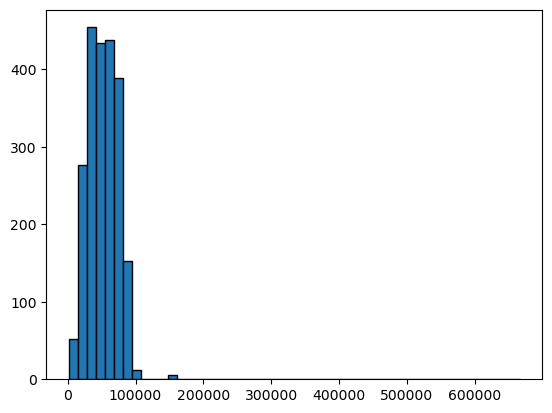

In [9]:
# see the distribution of the col: Income
plt.hist(df["Income"], bins=50, edgecolor="black")
plt.show()

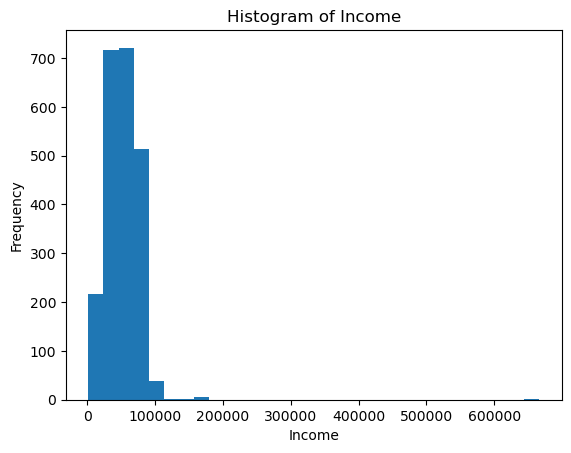

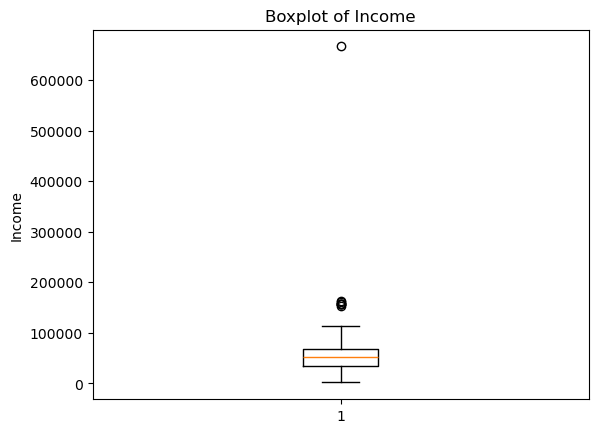

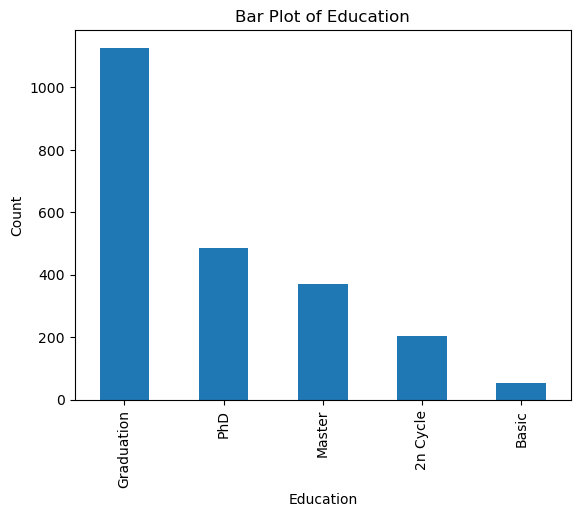

In [10]:
# Histogram
plt.hist(df["Income"].dropna(), bins=30)
plt.title("Histogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.boxplot(df["Income"].dropna())
plt.title("Boxplot of Income")
plt.ylabel("Income")
plt.show()

# Bar plot (for categorical data)
df["Education"].value_counts().plot(kind="bar")
plt.title("Bar Plot of Education")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

##### Handling missing values

In [11]:
median_income = df['Income'].median()

# Fill missing values with the median
df['Income'] = df['Income'].fillna(median_income)

# Verify that there are no more missing values
print(df['Income'].isnull().sum())

0


##### Feature engineering

In [12]:
# create a new col: Age

df['Age'] = 2026 - df['Year_Birth']
df['Age']

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2240, dtype: int64

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [14]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

reference_date = df['Dt_Customer'].max()
df['Customer_tenure_days'] = (reference_date - df['Dt_Customer']).dt.days
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [15]:
# create col: total_spending
spending_cols = [
		"MntWines",
		"MntFruits",
		"MntMeatProducts",
		"MntFishProducts",
		"MntSweetProducts",
		"MntGoldProds",
]
df['Total_Spending'] = df[spending_cols].sum(axis=1)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [16]:
# create a col for spending for children
df['total_children'] = df['Kidhome'] + df['Teenhome']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [17]:
# re-categorize the col: education

df['Education'] = df['Education'].map({"Basic":"Undergraduate", "2n Cycle":"Undergraduate", "Graduation":"Graduate","Master":"Post-Graduate","PhD":"Post-Graduate"})

In [18]:
df['Education'].value_counts()

Education
Graduate         1127
Post-Graduate     856
Undergraduate     257
Name: count, dtype: int64

In [19]:
df['Education'].isnull().sum()

np.int64(0)

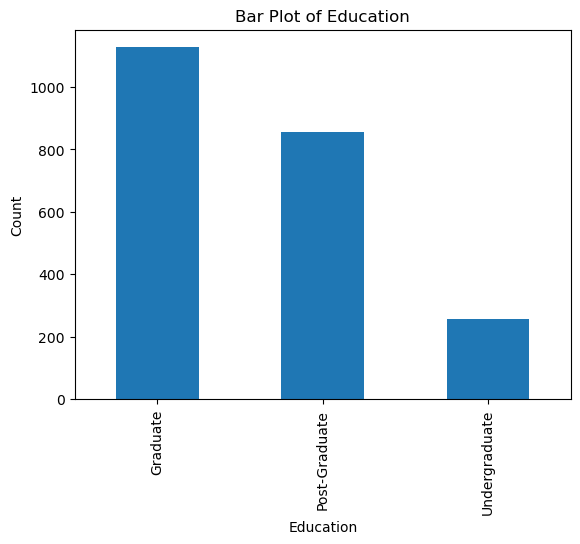

In [20]:
df['Education'].value_counts().plot(kind='bar')
plt.title("Bar Plot of Education")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

In [21]:
df['Marital_Status'].isnull().sum()

np.int64(0)

In [22]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [23]:
# marital status

df['Living_with'] = df['Marital_Status'].replace({"Married":"partner", "Together":"partner", "Single":"Alone", "Divorced":"Alone", "Absurd":"Alone", "YOLO":"Alone", "Widow":"Alone"})

df['Living_with'].value_counts()

Living_with
partner    1444
Alone       796
Name: count, dtype: int64

In [24]:
df[df['Living_with'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,total_children,Living_with


##### Data Preprocessing

In [25]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,total_children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,partner
4,5324,1981,Post-Graduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,partner


In [26]:
# drop the columns 

cols = ['ID', 'Year_Birth', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer']
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = [*cols, *spending_cols]

df.drop(cols_to_drop,axis=1,inplace=True) 		# drop the cols of no use
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,Post-Graduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


In [27]:
print(df.shape)
print(original_dataset.shape)

(2240, 15)
(2240, 22)


In [28]:
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,Post-Graduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


#### Outliers

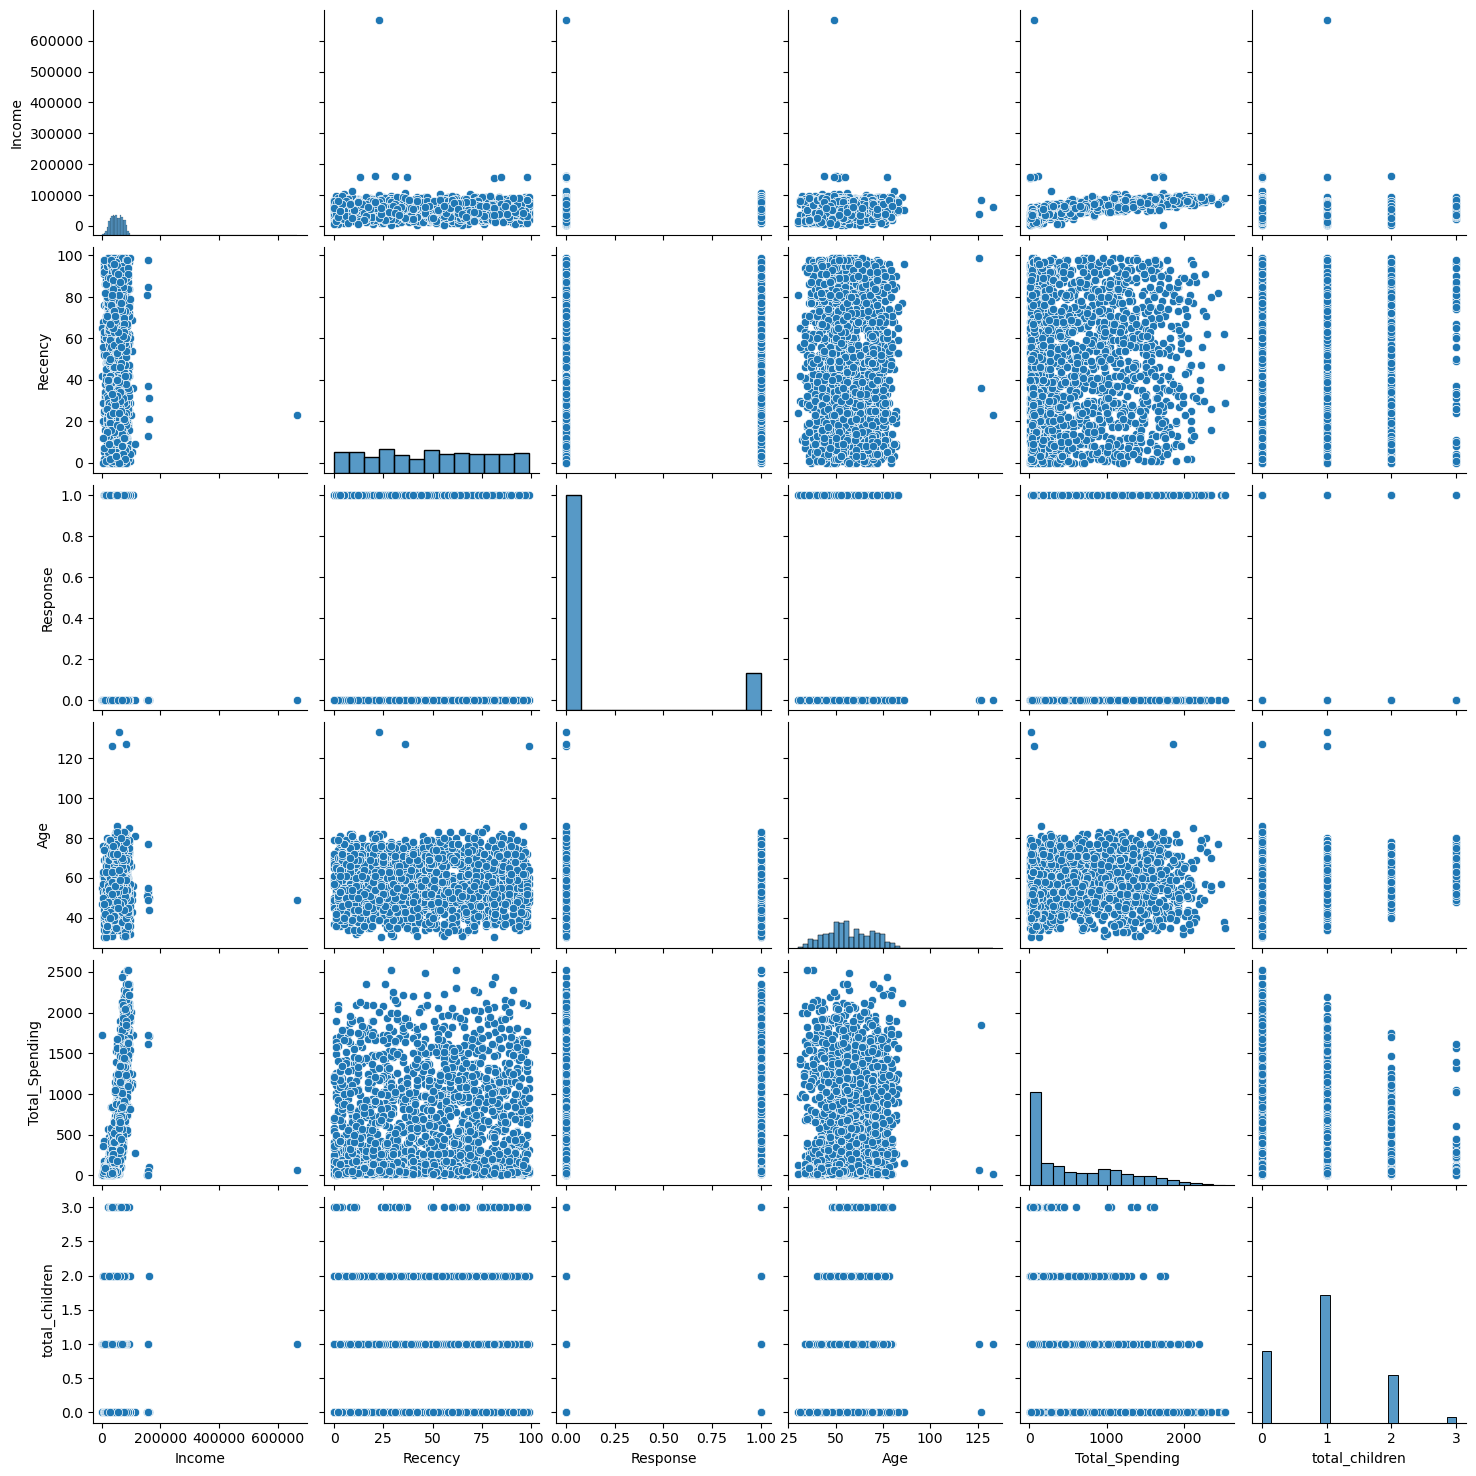

In [29]:
cols = ['Income', 'Recency', 'Response',
        'Age', 'Total_Spending', 'total_children']

sns.pairplot(df[cols])
plt.show()

In [30]:
# Remove outliers

df = df[df['Age'] < 90]
df = df[df['Income'] < 600_000]

In [31]:
df[df['Age']>90]
print(df[df['Income'] > 600000])

Empty DataFrame
Columns: [Education, Income, Recency, NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth, Complain, Response, Age, Customer_tenure_days, Total_Spending, total_children, Living_with]
Index: []


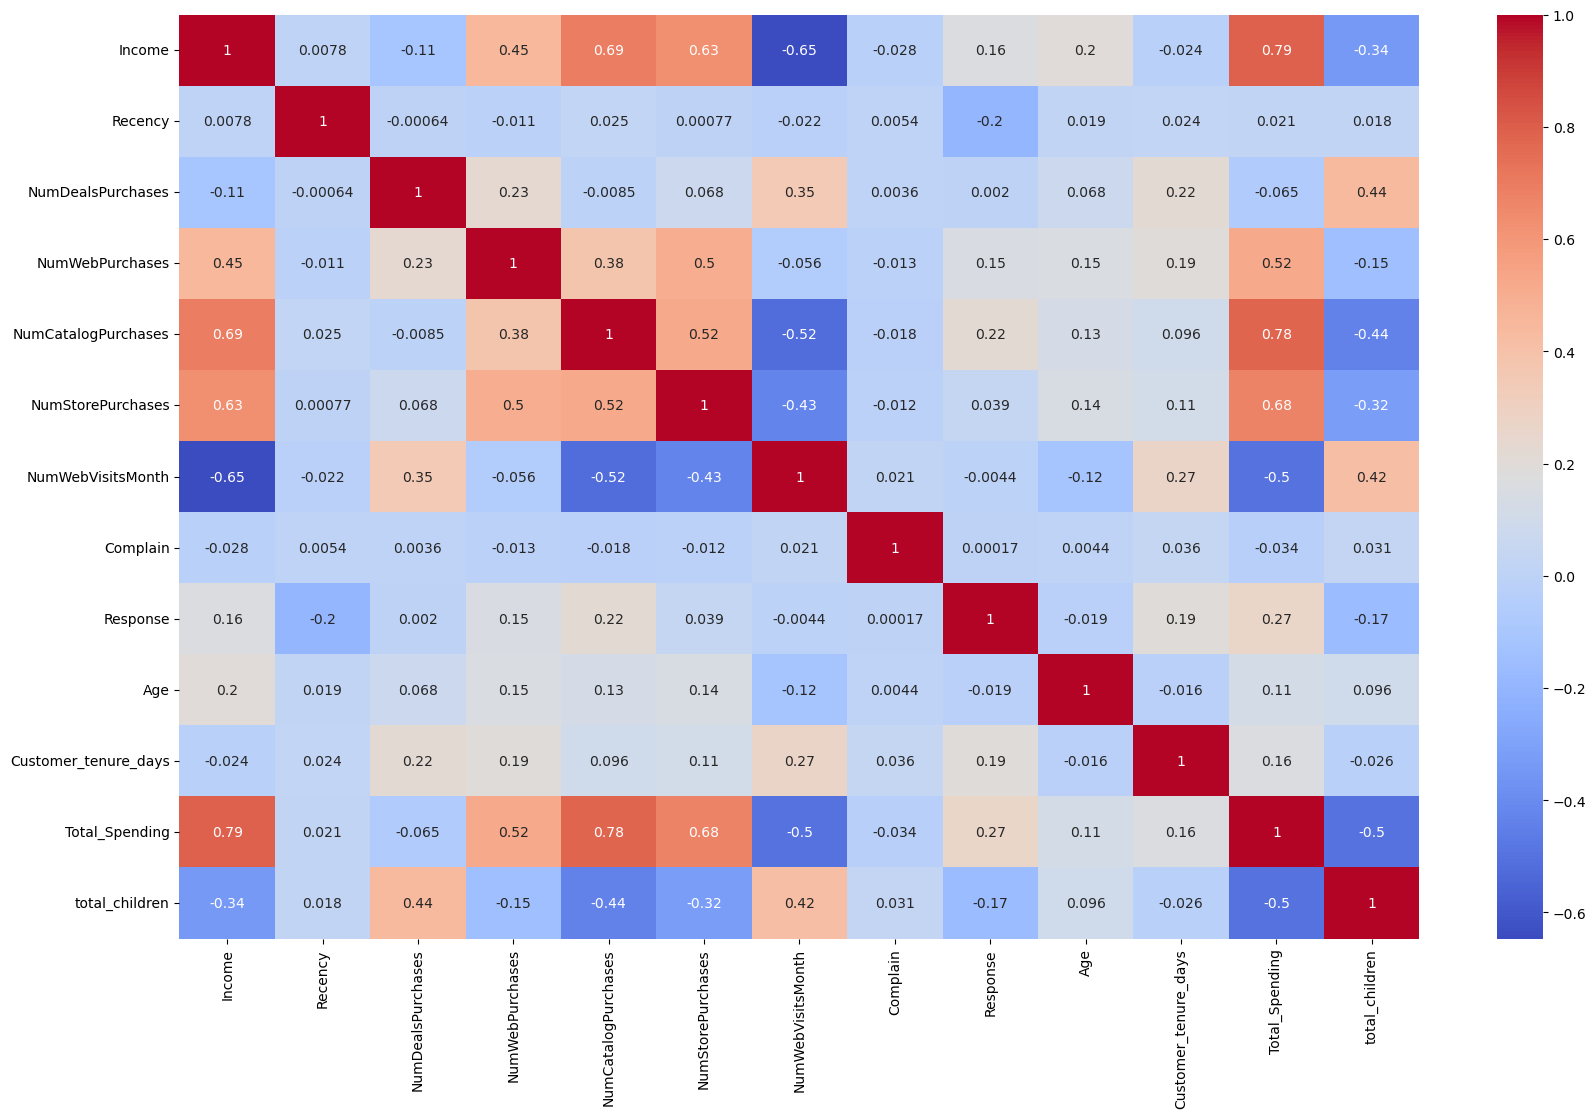

In [32]:
# correlation matrix 
plt.figure(figsize=(20,12))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [33]:
df.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_tenure_days', 'Total_Spending', 'total_children',
       'Living_with'],
      dtype='object')

In [34]:
# one hot encoding for categorical columns

from sklearn.preprocessing import OneHotEncoder
cat_cols = ['Education', 'Living_with']
ohe = OneHotEncoder()
encoded_cols = ohe.fit_transform(df[cat_cols])
print(encoded_cols)
enc_df = pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df.index)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4472 stored elements and shape (2236, 5)>
  Coords	Values
  (0, 0)	1.0
  (0, 3)	1.0
  (1, 0)	1.0
  (1, 3)	1.0
  (2, 0)	1.0
  (2, 4)	1.0
  (3, 0)	1.0
  (3, 4)	1.0
  (4, 1)	1.0
  (4, 4)	1.0
  (5, 1)	1.0
  (5, 4)	1.0
  (6, 0)	1.0
  (6, 3)	1.0
  (7, 1)	1.0
  (7, 4)	1.0
  (8, 1)	1.0
  (8, 4)	1.0
  (9, 1)	1.0
  (9, 4)	1.0
  (10, 0)	1.0
  (10, 4)	1.0
  (11, 2)	1.0
  (11, 4)	1.0
  (12, 0)	1.0
  :	:
  (2223, 4)	1.0
  (2224, 0)	1.0
  (2224, 3)	1.0
  (2225, 2)	1.0
  (2225, 4)	1.0
  (2226, 0)	1.0
  (2226, 4)	1.0
  (2227, 0)	1.0
  (2227, 3)	1.0
  (2228, 1)	1.0
  (2228, 3)	1.0
  (2229, 0)	1.0
  (2229, 3)	1.0
  (2230, 0)	1.0
  (2230, 4)	1.0
  (2231, 0)	1.0
  (2231, 4)	1.0
  (2232, 1)	1.0
  (2232, 4)	1.0
  (2233, 0)	1.0
  (2233, 3)	1.0
  (2234, 1)	1.0
  (2234, 4)	1.0
  (2235, 1)	1.0
  (2235, 4)	1.0


In [35]:
# concatenate the df and encoded df
df = pd.concat([df.drop(columns=cat_cols), enc_df], axis=1)
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,total_children,Education_Graduate,Education_Post-Graduate,Education_Undergraduate,Living_with_Alone,Living_with_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


##### Scaling

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = df
X_scaled = scaler.fit_transform(X)
X_scaled[10:]

array([[-0.02667925, -1.31658776, -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [-2.07657691,  0.34139707, -0.68613742, ...,  2.78722576,
        -0.74204052,  0.74204052],
       [ 0.51761351,  1.13584813, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

##### Visualize

In [37]:
X_scaled.shape

(2236, 18)

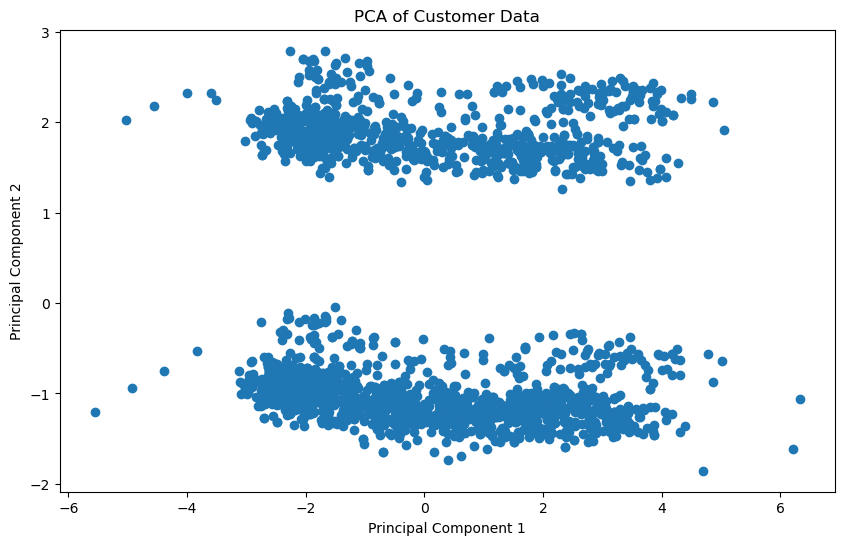

In [38]:
# 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# plot
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=1)
plt.title("PCA of Customer Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [39]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

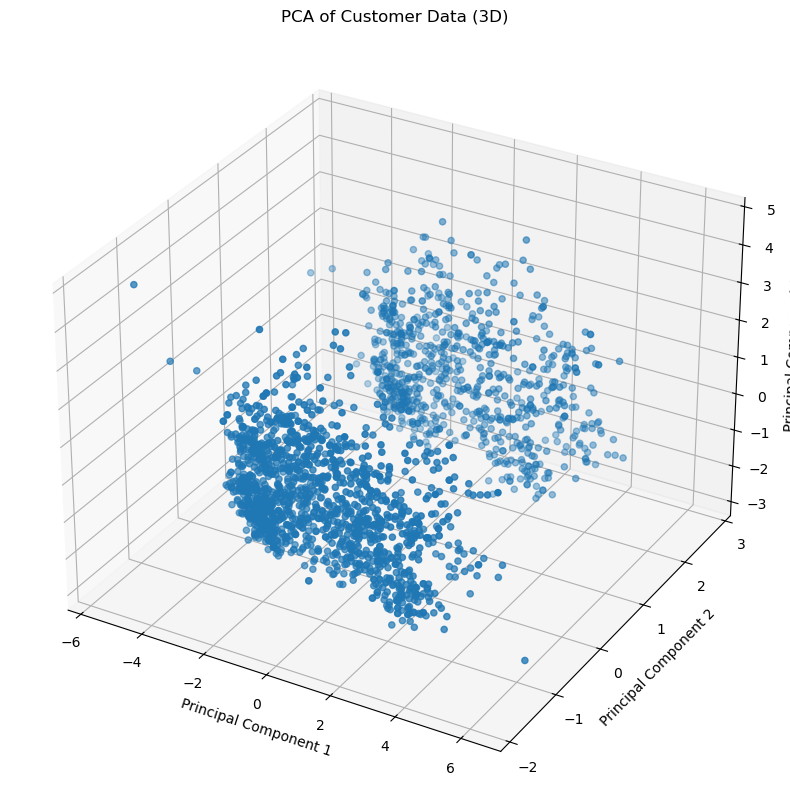

In [40]:
# 3D

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_title("PCA of Customer Data (3D)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
plt.show()

##### Find optimal value of k

In [41]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit_predict(X_pca)
  wcss.append(kmeans.inertia_)

print(wcss)

[18093.257793324534, 10760.84340175822, 8830.28871724305, 6650.969417658874, 5006.161168001194, 4396.308699108102, 3857.633064427557, 3207.0576242216366, 3025.223255432561, 2651.4429891061263]


In [42]:
knee = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow
print(f"Optimal number of clusters: {optimal_k}")

Optimal number of clusters: 4


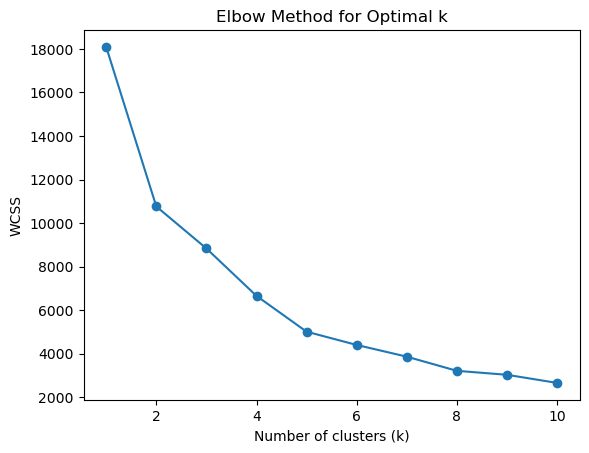

In [43]:
# plot 
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.show()

##### Silhoutte scores

In [44]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2,11):
	kmeans = KMeans(n_clusters=k, random_state=42)
	labels = kmeans.fit_predict(X_pca)
	score = silhouette_score(X_pca, labels)
	silhouette_scores.append(score)


print(silhouette_scores)

[np.float64(0.37157939079768293), np.float64(0.3076881927475405), np.float64(0.35809961595977), np.float64(0.40001521476630825), np.float64(0.3992918389857857), np.float64(0.40262087405590397), np.float64(0.4050858828691931), np.float64(0.4011889704652789), np.float64(0.40291173364826643)]


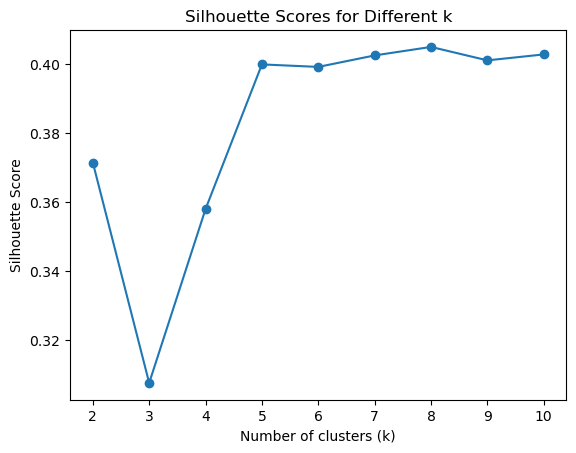

In [45]:
# plot
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

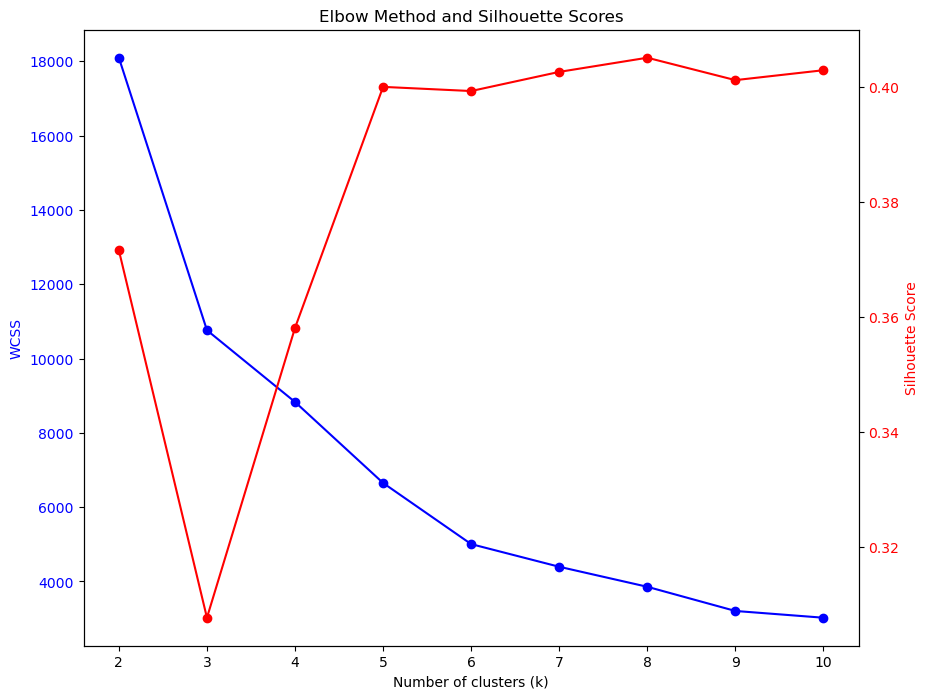

In [46]:
# combined plot

k_range = range(2,11)
fig, ax1 = plt.subplots(figsize = (10,8))
ax1.plot(k_range, wcss[:len(k_range)], marker='o', color='blue')
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("WCSS", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker='o', color='red')
ax2.set_ylabel("Silhouette Score", color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title("Elbow Method and Silhouette Scores")
plt.show()

In [47]:
# apply k - means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)
labels_kmeans

array([2, 3, 2, ..., 2, 1, 1], dtype=int32)

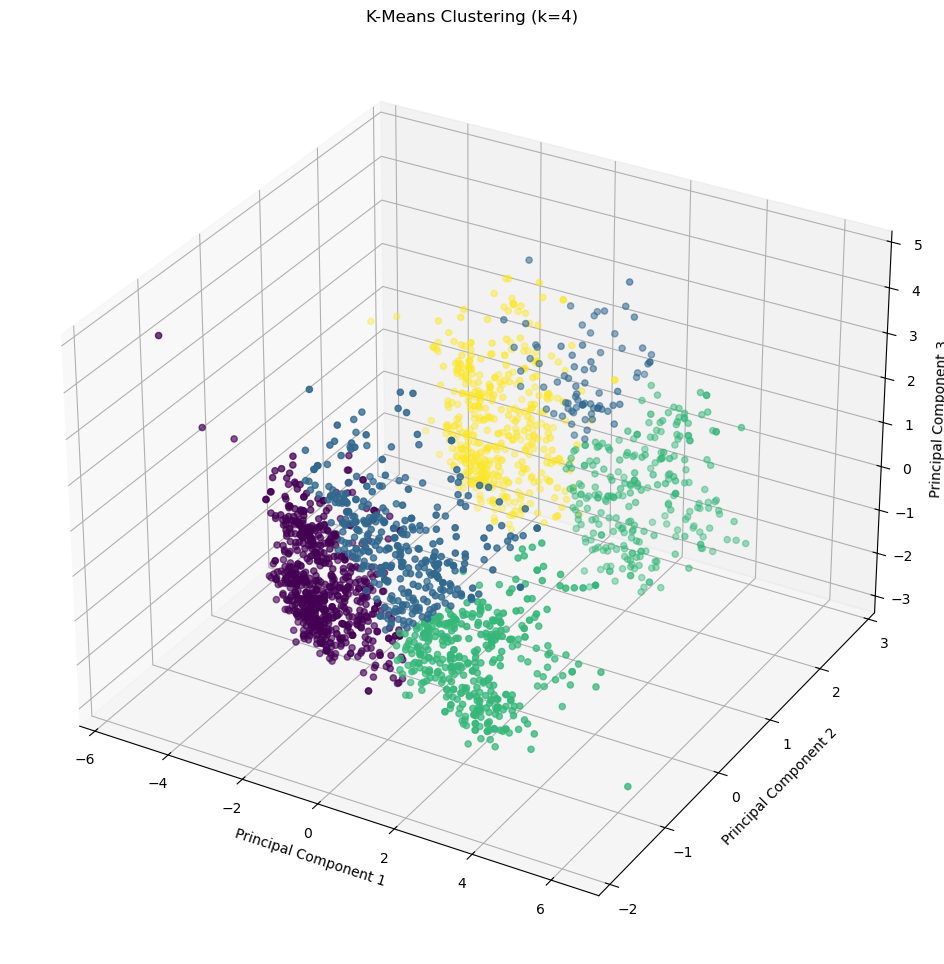

In [48]:
fig = plt.figure(figsize=(14,12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)
ax.set_title("K-Means Clustering (k=4)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
plt.show()

##### Aglomerative clustering

In [49]:
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)
labels_agg

array([3, 2, 1, ..., 3, 1, 0])

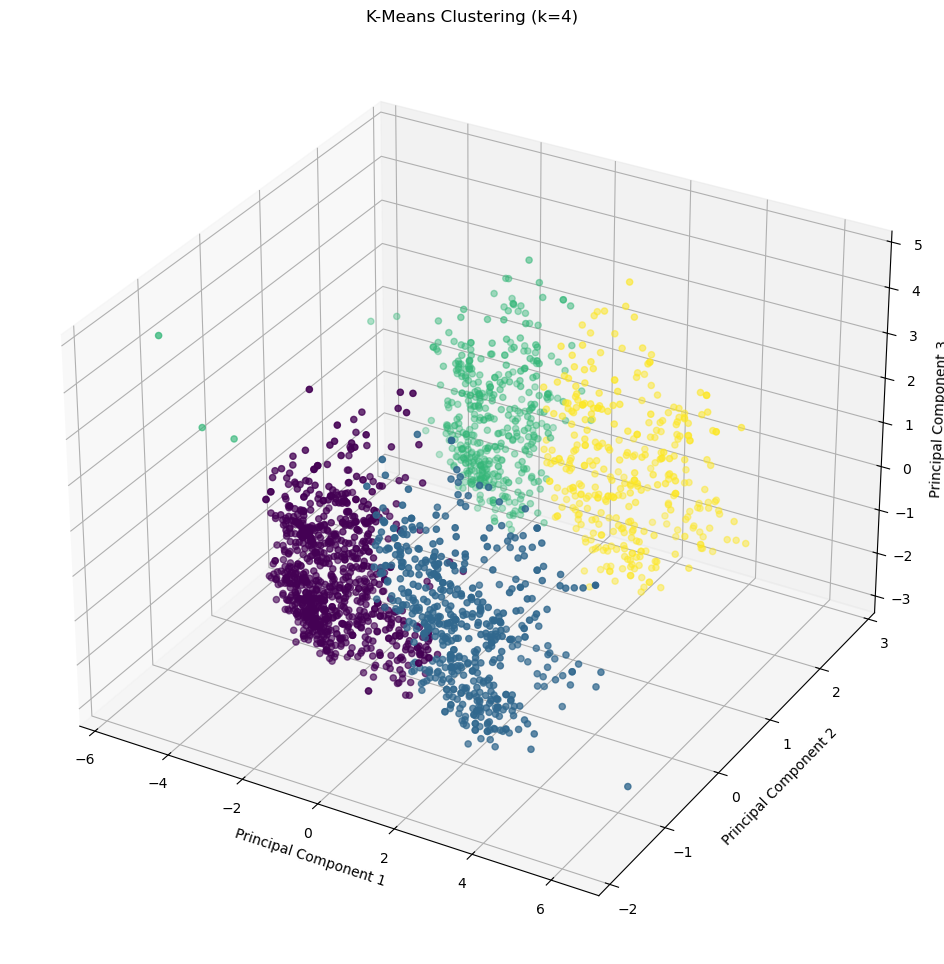

In [50]:
# plot
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)
ax.set_title("K-Means Clustering (k=4)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
plt.show()

#### Characterization of clusters

In [54]:
df.drop(columns='labels', axis=1)
df['clusters'] = labels_agg
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,total_children,Education_Graduate,Education_Post-Graduate,Education_Undergraduate,Living_with_Alone,Living_with_partner,labels,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0,0


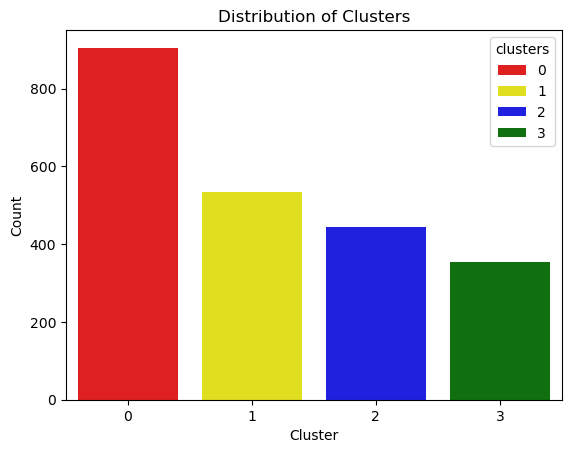

In [57]:
# countplot
pal = ['red', 'yellow', 'blue', 'green']
sns.countplot(x='clusters', palette=pal, data=df, hue=df['clusters'])
plt.title("Distribution of Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()